<a href="https://colab.research.google.com/github/tbodtcher/Mountainland_Capstone_Project/blob/main/tom_bodtcher_final_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import auth
auth.authenticate_user()

In [3]:
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "tom-bodtcher-capstone"
client = bigquery.Client(project=PROJECT_ID)

In [4]:
query = """
SELECT *
FROM `tom-bodtcher-capstone.final_data.capstone_data`
"""

df = client.query(query).to_dataframe()

df.head()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,...,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
0,P01892,24,Male,172.1,49.2,16.61,USA,Manager,Married,05:14,...,Low,Low,Medium,Low,Low,84.8,Excellent,86.9,Excellent,True
1,P07230,24,Female,162.9,47.8,18.01,India,Doctor,Married,04:31,...,Low,Low,Low,Low,Low,100.0,Excellent,100.0,Excellent,True
2,P01251,18,Male,183.9,56.8,16.80,South Korea,Retired,Married,06:25,...,Low,Low,Low,Low,Medium,85.7,Excellent,94.1,Excellent,True
3,P00240,18,Male,171.4,58.6,19.93,India,Doctor,Married,05:11,...,Low,Low,Low,Low,Low,92.5,Excellent,98.8,Excellent,True
4,P08190,21,Male,170.0,67.3,23.28,Brazil,Retired,Married,07:11,...,Low,Low,Low,Low,Low,63.5,Average,72.5,Average,False


In [5]:
df.shape

(10000, 64)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 64 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Person_ID                       10000 non-null  object 
 1   Age                             10000 non-null  Int64  
 2   Gender                          10000 non-null  object 
 3   Height_cm                       10000 non-null  float64
 4   Weight_kg                       10000 non-null  float64
 5   BMI                             10000 non-null  float64
 6   Country                         10000 non-null  object 
 7   Occupation                      10000 non-null  object 
 8   Marital_Status                  10000 non-null  object 
 9   Wake_Up_Time                    10000 non-null  object 
 10  Sleep_Time                      10000 non-null  object 
 11  Sleep_Duration_Hours            10000 non-null  float64
 12  Sleep_Quality_Score             1

In [7]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Sleep_Duration_Hours,Sleep_Quality_Score,Number_of_Night_Awakenings,Weekend_Sleep_Difference_Hours,Nap_Frequency_Per_Week,Screen_Time_Before_Bed_Hours,...,Fatigue_Level_Score,Immune_Health_Score,Mood_Score,Anxiety_Score,Depression_Risk_Score,Productivity_Score,Focus_Concentration_Score,Life_Satisfaction_Score,Health_Score,Healthy_Aging_Score
count,10000.0,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,10000.0,10000.000000,...,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000
mean,44.6667,168.649160,73.10734,25.626963,7.229332,6.020190,0.8391,1.027020,2.1208,1.144012,...,3.124640,6.56333,6.779650,5.133470,2.184520,7.06533,6.85799,7.416720,74.201360,74.812320
std,17.5172,9.876706,16.29195,4.870317,1.118486,1.585689,0.936215,0.787941,1.905196,1.044281,...,1.705843,1.06034,1.255232,1.496242,1.286404,1.14750,0.95254,1.147736,12.266227,14.627688
min,18.0,145.000000,33.60000,16.000000,4.000000,1.000000,0.0,-1.000000,0.0,0.000000,...,1.000000,2.60000,2.000000,1.000000,1.000000,2.80000,3.50000,2.900000,27.300000,12.400000
25%,29.75,161.400000,61.30000,22.170000,6.470000,4.900000,0.0,0.497500,0.75,0.330000,...,1.700000,5.90000,5.900000,4.100000,1.000000,6.30000,6.20000,6.600000,66.000000,65.300000
50%,43.0,168.200000,72.00000,25.580000,7.230000,6.000000,1.0,1.030000,2.0,0.810000,...,2.900000,6.60000,6.800000,5.100000,1.800000,7.00000,6.90000,7.400000,74.600000,75.700000
75%,58.0,175.500000,83.50000,28.862500,7.980000,7.100000,1.0,1.560000,3.0,1.650000,...,4.300000,7.30000,7.700000,6.200000,2.900000,7.90000,7.50000,8.200000,82.800000,85.700000
max,80.0,205.500000,166.60000,44.560000,10.000000,9.800000,6.0,3.810000,7.0,4.000000,...,10.000000,10.00000,10.000000,10.000000,8.800000,10.00000,10.00000,10.000000,100.000000,100.000000


In [8]:
df.isna().sum()

,0
Person_ID,0
Age,0
Gender,0
Height_cm,0
Weight_kg,0
...,...
Health_Score,0
Fitness_Level,0
Healthy_Aging_Score,0
Wellness_Category,0


In [9]:
df.groupby("Country")[["Health_Score", "Healthy_Aging_Score"]].mean().sort_values(by="Health_Score", ascending=False)

,Health_Score,Healthy_Aging_Score
Country,,
Brazil,75.160839,75.930769
Spain,75.101405,75.348946
USA,74.635627,75.212943
Nigeria,74.353404,75.110851
Pakistan,74.267391,74.650669
France,74.239958,74.666946
Japan,74.196402,74.616642
Australia,74.165331,74.810976
Mexico,74.156212,75.102037


In [10]:
df.groupby("Exercise_Type")["Health_Score"].mean().sort_values(ascending = False)

,Health_Score
Exercise_Type,
Sports,75.728947
Running,75.564219
Walking,75.393132
HIIT,75.326721
Swimming,75.279545
Weight Training,75.238599
Yoga,75.044734
Cycling,74.817610
None,61.889442


In [11]:
df.value_counts("Exercise_Type")

,count
Exercise_Type,
Weight Training,1513
Running,1498
Walking,1427
HIIT,1235
Yoga,997
Cycling,954
None,824
Swimming,792
Sports,760


In [12]:
df.groupby("Exercise_Type")["Sleep_Quality_Score"].mean().sort_values(ascending = False)

,Sleep_Quality_Score
Exercise_Type,
Swimming,6.077778
HIIT,6.062105
Running,6.034579
Cycling,6.034172
Walking,6.029222
Weight Training,5.996100
None,5.993204
Sports,5.971579
Yoga,5.970512


In [13]:
df['Protein_Intake_Grams'].describe()

,Protein_Intake_Grams
count,10000.000000
mean,97.307000
std,25.039683
min,30.000000
25%,80.000000
50%,97.500000
75%,114.200000
max,200.000000


In [14]:
df.groupby("Exercise_Type")["Protein_Intake_Grams"].mean().sort_values(ascending = False)

,Protein_Intake_Grams
Exercise_Type,
Walking,100.663700
Swimming,100.561111
HIIT,100.003644
Yoga,99.512437
Running,99.479372
Sports,99.452368
Weight Training,99.302512
Cycling,98.430608
None,70.762985


In [15]:
cols = [
    'Sleep_Duration_Hours',
    'Sleep_Quality_Score',
    'Exercise_Frequency_Per_Week',
    'Daily_Steps',
    'Social_Interaction_Score',
    'Resting_Heart_Rate',
    'Health_Score'
]

corr_matrix = df[cols].corr()
print(corr_matrix)

                             Sleep_Duration_Hours  Sleep_Quality_Score  \
Sleep_Duration_Hours                     1.000000             0.202494   
Sleep_Quality_Score                      0.202494             1.000000   
Exercise_Frequency_Per_Week              0.002265             0.009155   
Daily_Steps                              0.000490             0.010775   
Social_Interaction_Score                 0.000681             0.082874   
Resting_Heart_Rate                      -0.015190             0.001999   
Health_Score                             0.088305             0.479700   

                             Exercise_Frequency_Per_Week  Daily_Steps  \
Sleep_Duration_Hours                            0.002265     0.000490   
Sleep_Quality_Score                             0.009155     0.010775   
Exercise_Frequency_Per_Week                     1.000000     0.835759   
Daily_Steps                                     0.835759     1.000000   
Social_Interaction_Score                  

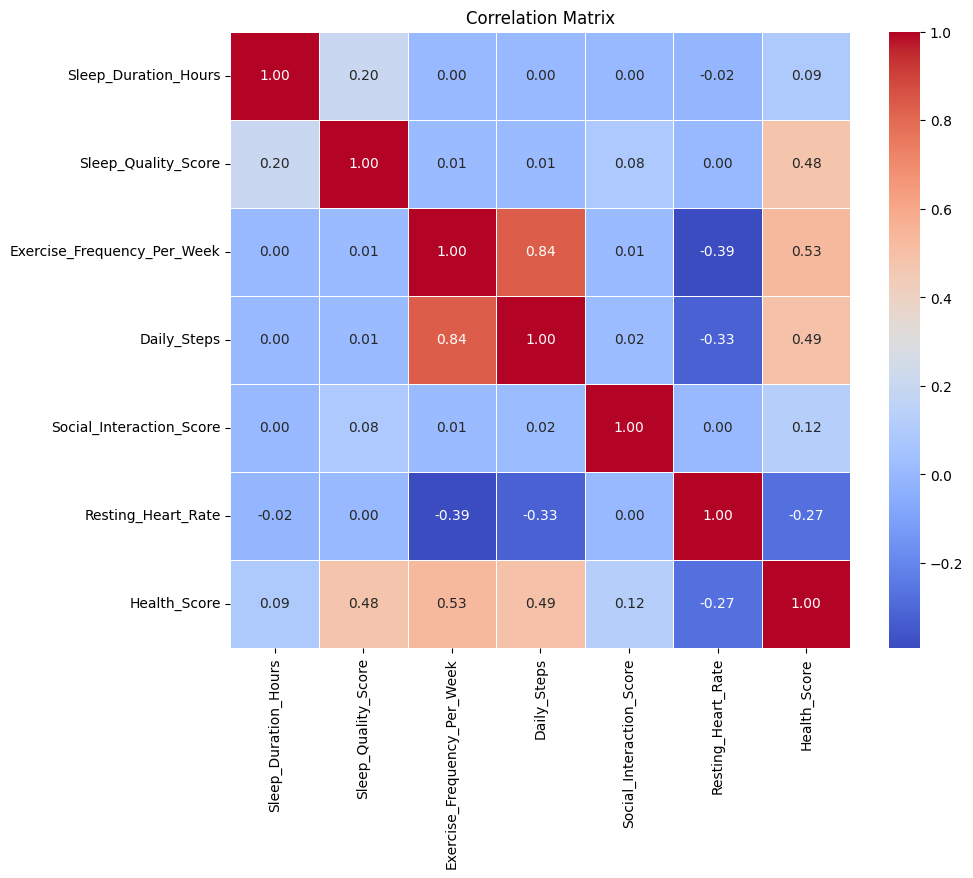

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
corr_matrix = df[cols].corr(numeric_only=True)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,      # show correlation values
    cmap='coolwarm', # colors
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix')
plt.show()

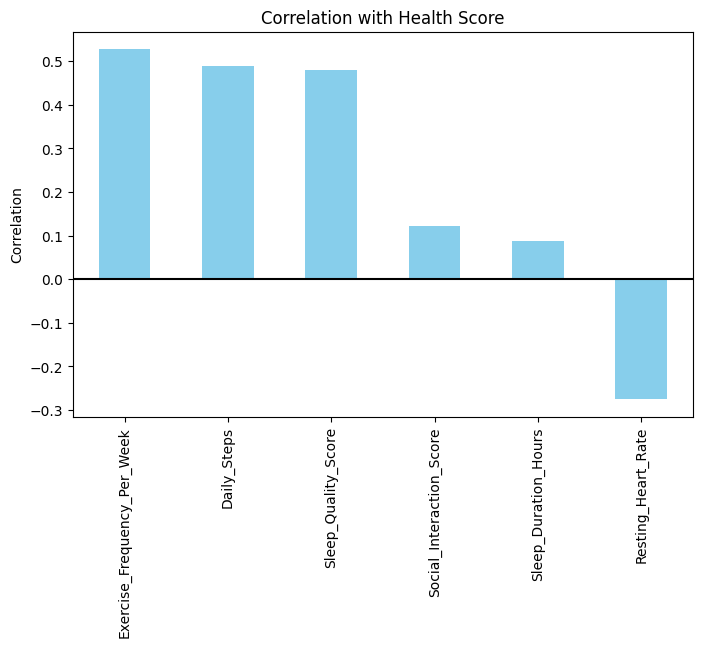

In [17]:
health_corr = corr_matrix['Health_Score'].sort_values(ascending=False)

health_corr.drop('Health_Score').plot(
    kind='bar',
    figsize=(8, 5),
    color='skyblue'
)

plt.title('Correlation with Health Score')
plt.ylabel('Correlation')
plt.axhline(0, color='black')
plt.show()

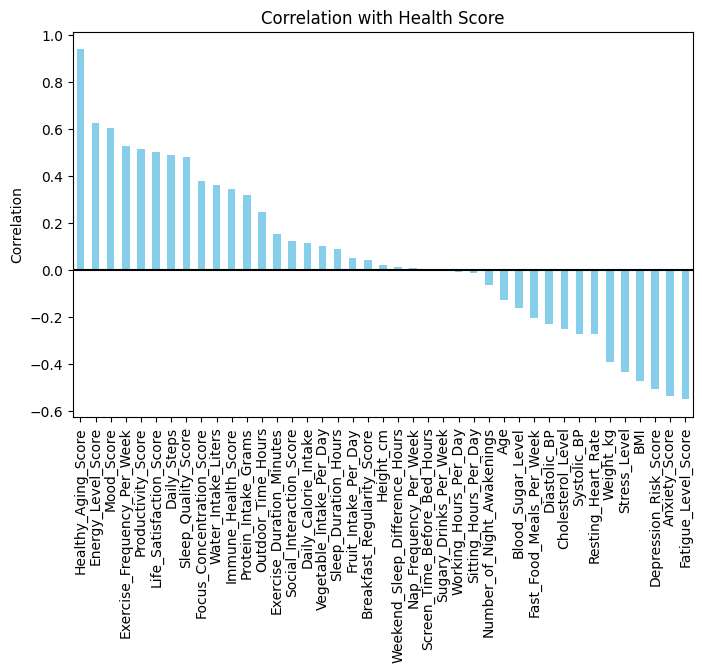

In [18]:
corr_matrix2 = df.select_dtypes(include='number').corr()

health_corr2 = corr_matrix2['Health_Score'].sort_values(ascending=False)

health_corr2.drop('Health_Score').plot(
    kind='bar',
    figsize=(8, 5),
    color='skyblue'
)

plt.title('Correlation with Health Score')
plt.ylabel('Correlation')
plt.axhline(0, color='black')
plt.show()

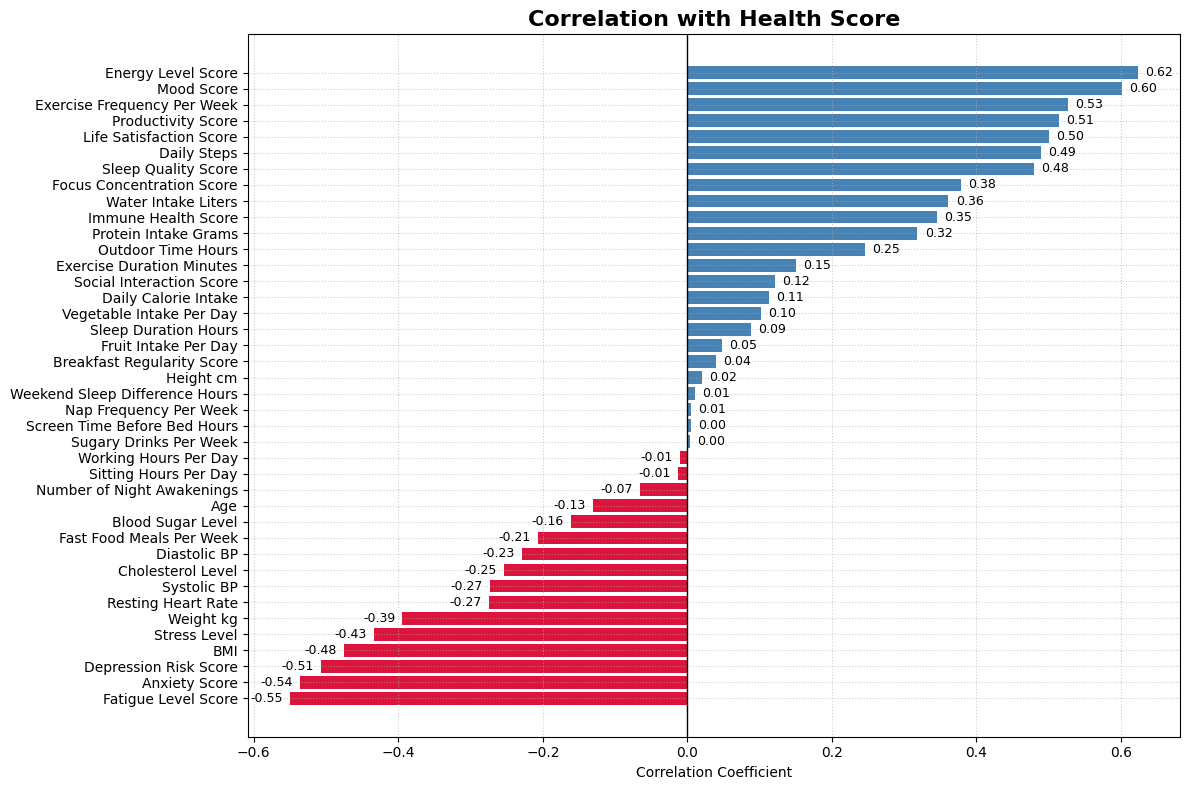

In [19]:
corr_matrix2 = df.select_dtypes(include='number').corr()

health_corr2 = (
    corr_matrix2['Health_Score']
    .drop(['Health_Score', 'Healthy_Aging_Score'])
    .sort_values()
)

health_corr2.index = health_corr2.index.str.replace('_', ' ')

colors = ['crimson' if x < 0 else 'steelblue'
          for x in health_corr2]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    health_corr2.index,
    health_corr2.values,
    color=colors
)

ax.axvline(0, color='black', linewidth=1)

ax.grid(axis='both', linestyle=':', alpha=0.6)

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.01 if width >= 0 else width - 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}',
        va='center',
        ha='left' if width >= 0 else 'right',
        fontsize=9
    )

ax.set_title(
    'Correlation with Health Score',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

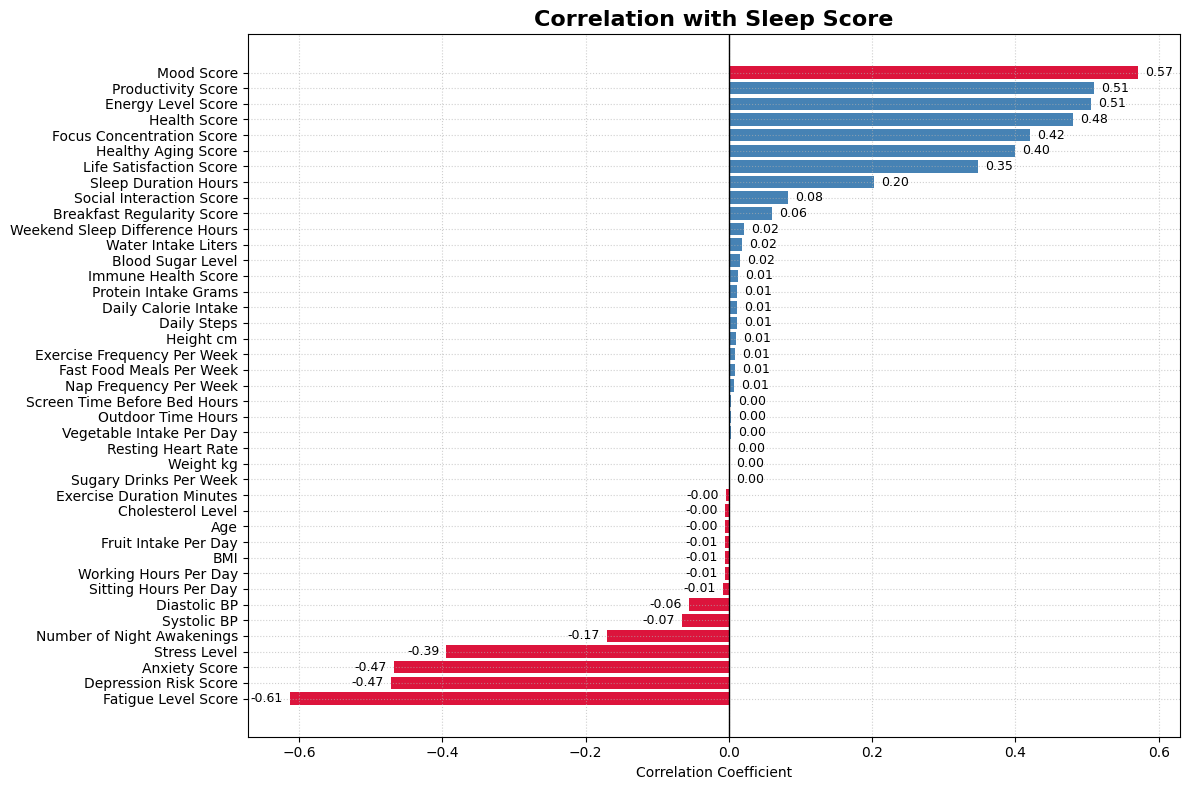

In [20]:
corr_matrix3 = df.select_dtypes(include='number').corr()

health_corr3 = (
    corr_matrix3['Sleep_Quality_Score']
    .drop('Sleep_Quality_Score')
    .sort_values()
)

health_corr3.index = health_corr3.index.str.replace('_', ' ')

colors = ['crimson' if x < 0 else 'steelblue'
          for x in health_corr2]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    health_corr3.index,
    health_corr3.values,
    color=colors
)

ax.axvline(0, color='black', linewidth=1)

ax.grid(axis='both', linestyle=':', alpha=0.6)

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.01 if width >= 0 else width - 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}',
        va='center',
        ha='left' if width >= 0 else 'right',
        fontsize=9
    )

ax.set_title(
    'Correlation with Sleep Score',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [25]:
encoded_df = pd.get_dummies(df, columns=['Country', 'Exercise_Type', 'Smoking_Status', 'Alcohol_Consumption'], dtype=int)
encoded_df.head()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Occupation,Marital_Status,Wake_Up_Time,Sleep_Time,...,Exercise_Type_Walking,Exercise_Type_Weight Training,Exercise_Type_Yoga,Smoking_Status_Current,Smoking_Status_Former,Smoking_Status_Never,Alcohol_Consumption_Heavy,Alcohol_Consumption_Light,Alcohol_Consumption_Moderate,Alcohol_Consumption_None
0,P01892,24,Male,172.1,49.2,16.61,Manager,Married,05:14,23:10,...,0,1,0,0,0,1,0,0,0,1
1,P07230,24,Female,162.9,47.8,18.01,Doctor,Married,04:31,22:43,...,0,0,0,0,1,0,1,0,0,0
2,P01251,18,Male,183.9,56.8,16.80,Retired,Married,06:25,00:08,...,1,0,0,0,0,1,0,1,0,0
3,P00240,18,Male,171.4,58.6,19.93,Doctor,Married,05:11,23:28,...,0,0,0,0,0,1,0,0,1,0
4,P08190,21,Male,170.0,67.3,23.28,Retired,Married,07:11,23:40,...,0,0,0,0,0,1,0,0,1,0


In [26]:
prefixes = (
    'Country_',
    'Exercise_Type_',
    'Smoking_Status_',
    'Alcohol_Consumption_'
)

encoded_cols = [
    col for col in encoded_df.columns
    if col.startswith(prefixes)
]

corrs = (
    encoded_df[encoded_cols]
    .corrwith(encoded_df['Health_Score'])
    .sort_values(ascending=False)
)

print(corrs)

Smoking_Status_Never             0.087521
Exercise_Type_Running            0.046640
Exercise_Type_Walking            0.039641
Exercise_Type_Sports             0.035718
Exercise_Type_Weight Training    0.035705
Alcohol_Consumption_Light        0.034570
Exercise_Type_HIIT               0.034440
Smoking_Status_Former            0.028773
Exercise_Type_Swimming           0.025780
Exercise_Type_Yoga               0.022882
Country_Brazil                   0.019268
Exercise_Type_Cycling            0.016316
Country_Spain                    0.015498
Country_USA                      0.014686
Alcohol_Consumption_None         0.010389
Alcohol_Consumption_Moderate     0.010331
Country_Nigeria                  0.002753
Country_Pakistan                 0.001358
Country_France                   0.000705
Country_Japan                   -0.000108
Country_Australia               -0.000725
Country_Mexico                  -0.000836
Country_Canada                  -0.003465
Country_Germany                 -0

In [27]:
corr_table = corrs.reset_index()
corr_table.columns = ['Feature', 'Correlation_with_Health_Score']

print(corr_table)

                          Feature  Correlation_with_Health_Score
0            Smoking_Status_Never                       0.087521
1           Exercise_Type_Running                       0.046640
2           Exercise_Type_Walking                       0.039641
3            Exercise_Type_Sports                       0.035718
4   Exercise_Type_Weight Training                       0.035705
5       Alcohol_Consumption_Light                       0.034570
6              Exercise_Type_HIIT                       0.034440
7           Smoking_Status_Former                       0.028773
8          Exercise_Type_Swimming                       0.025780
9              Exercise_Type_Yoga                       0.022882
10                 Country_Brazil                       0.019268
11          Exercise_Type_Cycling                       0.016316
12                  Country_Spain                       0.015498
13                    Country_USA                       0.014686
14       Alcohol_Consumpt

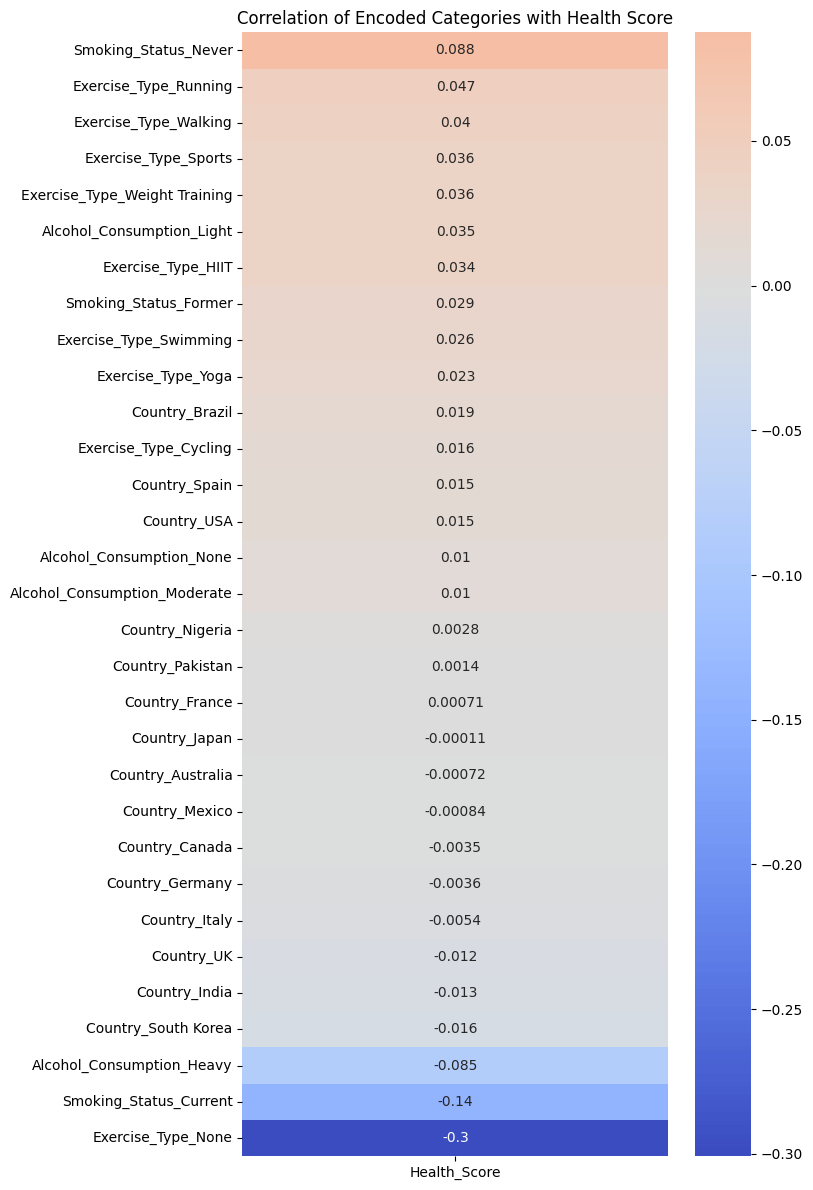

In [29]:
plt.figure(figsize=(8, 12))
sns.heatmap(
    corrs.to_frame('Health_Score'),
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.title('Correlation of Encoded Categories with Health Score')
plt.tight_layout()
plt.show()

In [31]:
df.to_csv('capstone_data.csv', index=False)